# Imports

In [ ]:
# installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

In [ ]:

import sys
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt

# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"PFM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)

from nnerror.networks import FNO_im2spec, CustomDecoder
from nnerror.training_functions import err_estimation, train_model, predict_spectra
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, plot_error_prediction, plot_spectra
from BEPS_functions import BEPS_image_spectral_pairs, extract_beps_data


# Get data

(1521, 12, 12) (1521, 256) (256,)


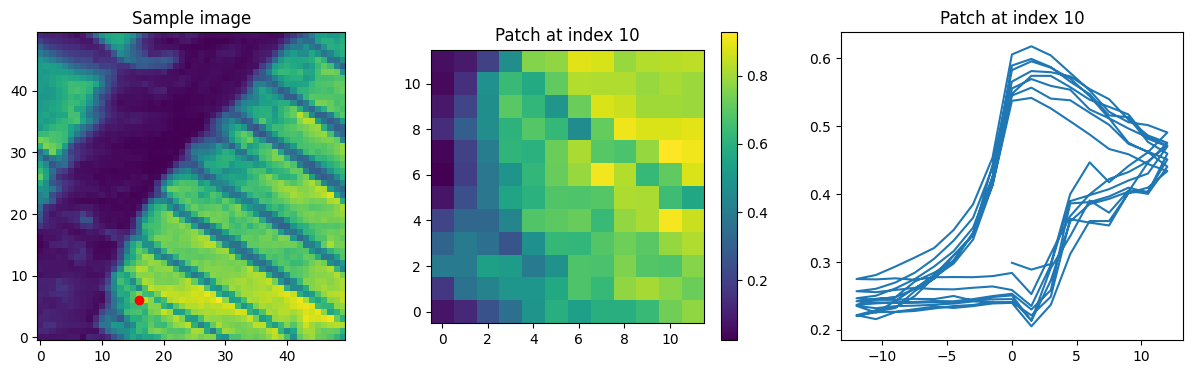

In [ ]:
beps_folder = r"data/BEPS_data" if not running_on_colab() else r"notebooks/PFM/data/BEPS_data"
beps_file = os.path.join(beps_folder, "PTO_BEPS_0p85um.npz")

full_image, spectra, v_step = extract_beps_data(beps_file)
images, spectra, coordinates, vstep = BEPS_image_spectral_pairs(beps_file, window_size=12, step=1)

print(images.shape, spectra.shape, vstep.shape)


fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 10

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(vstep, spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

## Test train split

In [3]:
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test = train_test_split(
    images, spectra, test_size=0.3, random_state=42
)

print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (857, 16, 16)
images_test shape: (368, 16, 16)
spectra_train shape: (857, 256)
spectra_test shape: (368, 256)


In [ ]:
print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (1225, 16, 16)
spectra shape: (1225, 256)


# FNO im2spec Model

Minimal single-model workflow: FNOim2spec -> error estimation -> fused error model

100%|██████████| 30/30 [00:11<00:00,  2.62it/s]


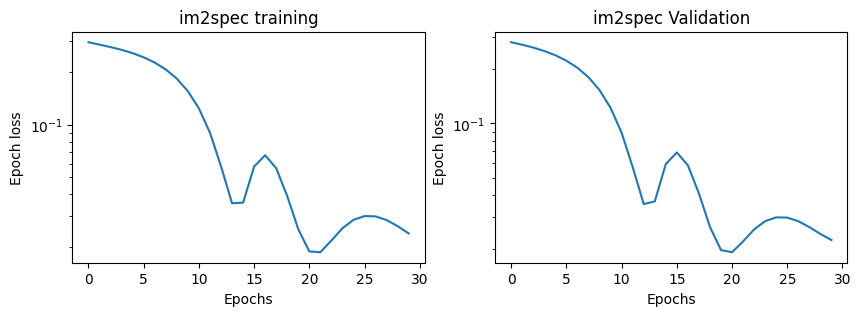

im2spec final train loss: 0.024006154388189316
im2spec final internal val loss: 0.02248748391866684
im2spec held-out test loss: 0.02210388518869877


In [ ]:

# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
imspec_model = FNO_im2spec(
    target_size=out_dim,
    latent_dim=8,
    hidden_channels=32,
    n_modes=(8, 8),
    n_layers=4,
).to(device)

im2spec_training_dataset = TensorDataset(
    torch.tensor(images_train, dtype=torch.float32),
    torch.tensor(spectra_train, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.
n_epochs_im2spec = 30
plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=1,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)


# Error data and training

In [6]:

# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images, spectra)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)

print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)

# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)


error_mean shape: (1225,)
error_vector shape: (1225, 256)
error_targets shape: (1225, 1)


100%|██████████| 50/50 [00:25<00:00,  1.94it/s]


error model final train loss: 0.014454399235546589
error model final val loss: 0.013699213974177837


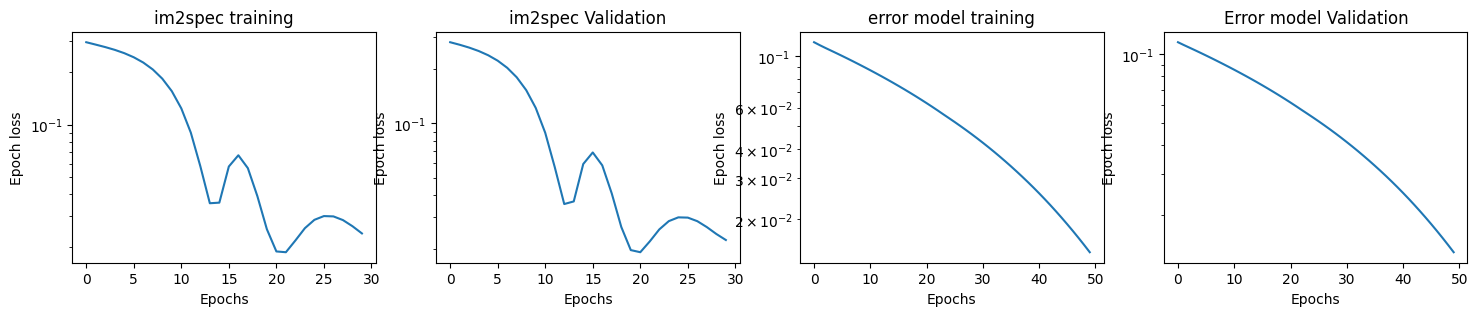

In [7]:

# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images, dtype=torch.float32),
    torch.tensor(error_targets, dtype=torch.float32),
)

n_epochs_error = 50
error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=1,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_error,
    partial_train=True,
)

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])

plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

In [8]:
#Predict errors on the entire dataset using the trained error model
predicted_errors = predict_spectra(error_model, images, ensemble=False)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

predicted_errors shape: (1225,)
predicted_errors range: 0.018894270062446594 0.018902748823165894


# Acquisiton function

In [9]:
from nnerror.training_functions import distance_acq_fn
from nnerror.plot_functions import plot_error_prediction, plot_spectra

aq_ind, aq_fn = distance_acq_fn(predicted_errors, beta = 0, lambda_ = 1, sample_next_points = 1, exclude_indices = [])



# Im2spec reconstruction

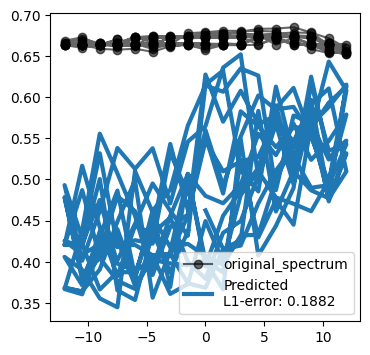

In [10]:
for ind in aq_ind:

    # Acquisition point
    next_coordinate = coordinates[ind]
    predicted_spectra = predict_spectra(imspec_model, images[ind:ind+1], ensemble = False)

    spectral_error, _, _ = err_estimation(imspec_model, images[ind:ind+1], spectra[ind:ind+1])
    # error_log.append(spectral_error.mean())
    plot_spectra([predicted_spectra], spectra[ind], spectral_error.mean(), xdata = vstep)

# Error prediction

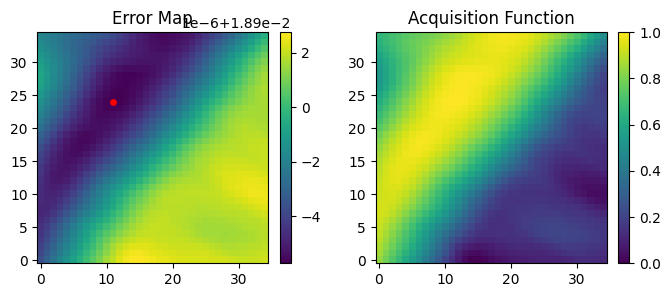

In [11]:
plot_error_prediction(predicted_errors, aq_fn, coordinates, aq_ind)